In [1]:
import pandas as pd
from torch.utils.data import DataLoader, Dataset
import os

from typing import Callable

from PIL import Image

from jormungandr.utils.image_processors import (
    DetrImageProcessorNoPadBBoxUpdate as DetrImageProcessor,
)
from jormungandr.utils.seed import build_torch_generator, seed_worker

In [2]:

model_name = "facebook/detr-resnet-50"
image_processor: DetrImageProcessor | None = None
try:
    image_processor = DetrImageProcessor.from_pretrained(
        model_name, force_download=True
    )
except Exception as e:
    print(f"Error occurred while loading image processor: {e}")
    print(
        "There is likely an issue with the Hugging Face Hub or your internet connection. If you have previously loaded the model, it should be cached locally. Attempting to load from cache..."
    )
    image_processor = DetrImageProcessor.from_pretrained(
        model_name, local_files_only=True
    )


def _collate_fn_vod(batch):
    all_images = []
    all_annotations = []
    for item in batch:
        all_images.extend(item["pixel_values"])
        all_annotations.extend(item["labels"])

    encoded = image_processor(
        images=all_images, annotations=all_annotations, return_tensors="pt"
    )

    for label in encoded["labels"]:
        if "area" in label:
            orig_h, orig_w = label["orig_size"].tolist()
            size_h, size_w = label["size"].tolist()
            label["area"] = label["area"] * (orig_h / size_h) * (orig_w / size_w)

    return {
        "pixel_values": encoded["pixel_values"],
        "pixel_mask": encoded["pixel_mask"],
        "labels": encoded["labels"],
    }


class VODDataset(Dataset):
    # sequence_dirs: list of directories, each containing frames of a video sequence
    # n_frames: number of consecutive frames to include in each clip
    # get_item should return a dict with keys "pixel_values" (list of tensors) and "labels" (list of dicts)
    # "pixel_values" should be a list of tensors of shape (Frames, Channels, Height, Width)
    # "labels" should be a list of dicts, one per frame, each containing the COCO-style annotations for that frame
    def __init__(
        self,
        sequence_dirs: list[str],
        n_frames: int = 4,
        # sampling_strategy: str = "consecutive",  # or "random"
        transform: Callable | None = None,
    ):
        self.n_frames = n_frames
        self.transform = transform
        self.sequence_dirs = sequence_dirs
        self.columns = [
            "frame_number",
            "identity_number",
            "bbox_left",
            "bbox_top",
            "bbox_width",
            "bbox_height",
            "confidence_score",
            "class",
            "visibility",
        ]
        self.clips: list[tuple[str, list[str]]] = []
        self.gt_annotations: dict[str, pd.DataFrame] = {}

        """
        Sequence to sequence predictions: for each sequence, we can create multiple clips by sliding a window of size n_frames across the frames. For example, if a sequence has 10 frames and n_frames=4, we can create the following clips:
            - Clip 1: frames 1-4
            - Clip 2: frames 2-5
            - Clip 3: frames 3-6
        They also apply normal image augmentations: random horizontal flip and random resizing
        """
        """
        sequence_dir
        ├── img1/
        │   ├── 00001.jpg
        │   ├── 00002.jpg
        │   └── ...
        ├── gt/
        │   └── gt.txt
        └── sequence.ini

        """
        for seq_dir in sequence_dirs:
            img_dir = os.path.join(seq_dir, "img1")
            frame_files = sorted(
                [
                    f
                    for f in os.listdir(img_dir)
                    if f.endswith((".jpg", ".png", ".jpeg"))
                ]
            )
            for i in range(len(frame_files) - n_frames + 1):
                clip_frames = frame_files[i : i + n_frames]
                self.clips.append((seq_dir, clip_frames))
            gt_path = os.path.join(seq_dir, "gt", "gt.txt")
            self.prepare_dataframe(seq_dir, gt_path)

    def prepare_dataframe(self, seq_dir: str, gt_path: str):
        gt = pd.read_csv(gt_path, sep=",", header=None, names=self.columns)
        filtered_gt = gt.query("confidence_score != 0")
        filtered_gt["bbox"] = filtered_gt[
            ["bbox_left", "bbox_top", "bbox_width", "bbox_height"]
        ].values.tolist()
        filtered_gt = filtered_gt[["frame_number", "bbox", "class", "visibility"]]
        combined = (
            filtered_gt.groupby("frame_number")
            .agg({"bbox": list, "class": list, "visibility": list})
            .reset_index()
        )
        combined = combined.rename(columns={"class": "category"})
        self.gt_annotations[seq_dir] = combined

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, index):
        seq_dir: str
        clip_frames: list[str]
        seq_dir, clip_frames = self.clips[index]
        pixel_values = []
        labels = []
        for frame_file in clip_frames:
            image, annotation = self.load_image(seq_dir, frame_file)
            if self.transform is not None:
                image, annotation = self.transform(image, annotation)
            pixel_values.append(image)
            labels.append(annotation)
        # pixel_values = torch.stack(pixel_values)  # (Frames, Channels, Height, Width)
        return {"pixel_values": pixel_values, "labels": labels}

    def load_image(self, seq_dir: str, frame_file: str) -> tuple[Image.Image, dict]:
        frame_path = os.path.join(seq_dir, "img1", frame_file)
        img = Image.open(frame_path).convert("RGB")

        frame_number = int(os.path.splitext(frame_file)[0])
        gt = self.gt_annotations[seq_dir]

        rows = gt[gt["frame_number"] == frame_number]
        if rows.empty:
            return img, {"image_id": frame_number, "annotations": []}

        row = rows.iloc[0]
        annotations = [
            {
                "bbox": bbox,  # [x, y, w, h] absolute pixels
                "category_id": int(cat),
                "area": float(bbox[2] * bbox[3]),
                "iscrowd": 0,
            }
            for bbox, cat in zip(row["bbox"], row["category"])
        ]
        return img, {"image_id": frame_number, "annotations": annotations}


def create_vod_dataloader(
    path: str = "../data/",
    dataset_name: str = "mot17",
    n_frames: int = 4,
    batch_size: int = 1,
    seed: int = 42,
    shuffle: bool = True,
    collate_fn: Callable = _collate_fn_vod,
    val_split: float = 0.2,
) -> tuple[DataLoader, DataLoader]:
    data_path = os.path.join(path, dataset_name.upper(), "train")
    sequence_dirs = sorted(
        [
            os.path.join(data_path, d)
            for d in os.listdir(data_path)
            if os.path.isdir(os.path.join(data_path, d))
        ]
    )

    n_val = max(1, int(len(sequence_dirs) * val_split))
    train_dirs = sequence_dirs[:-n_val]
    val_dirs = sequence_dirs[-n_val:]

    train_dataset = VODDataset(train_dirs, n_frames=n_frames)
    val_dataset = VODDataset(val_dirs, n_frames=n_frames)

    train_generator = build_torch_generator(seed)
    val_generator = build_torch_generator(seed + 1)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn,
        worker_init_fn=seed_worker,
        generator=train_generator,
        num_workers=len(os.sched_getaffinity(0)),
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        worker_init_fn=seed_worker,
        generator=val_generator,
        num_workers=len(os.sched_getaffinity(0)),
        pin_memory=True,
    )
    return train_loader, val_loader


Error occurred while loading image processor: Force download failed due to the above error.
There is likely an issue with the Hugging Face Hub or your internet connection. If you have previously loaded the model, it should be cached locally. Attempting to load from cache...


In [3]:
train_path = "../data/MOT17/train/MOT17-02-FRCNN/"

train_loader, val_loader = create_vod_dataloader(
    path="../data/", dataset_name="mot17", n_frames=15, batch_size=1, 
)
for i, data in enumerate(train_loader):
    pixel_values, pixel_mask, labels = (
        data["pixel_values"],
        data["pixel_mask"],
        data["labels"],
    )
    # print(f"pixel_values shape: {pixel_values.shape}")
    # print(f"pixel_mask shape:   {pixel_mask.shape}")
    # print(f"Labels image_ids:   {[label['image_id'].item() for label in labels]}")

    break

/tmp/ipykernel_6950/3331207479.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_gt["bbox"] = filtered_gt[
/tmp/ipykernel_6950/3331207479.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_gt["bbox"] = filtered_gt[
/tmp/ipykernel_6950/3331207479.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

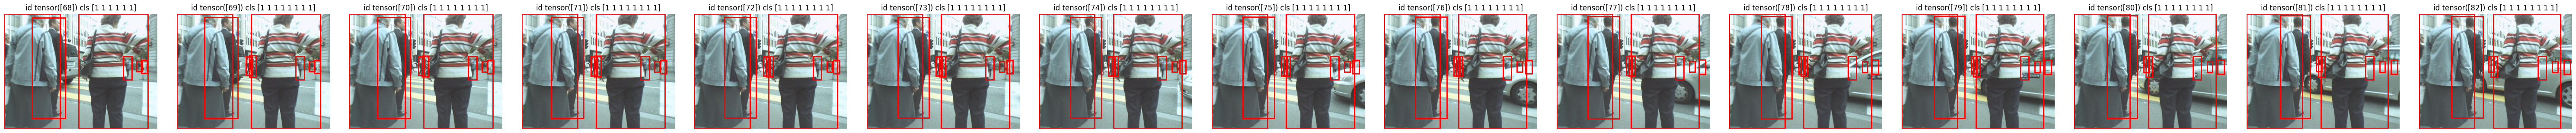

In [4]:
import numpy as np
import torch

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Use the existing batch variable if present, otherwise use data
batch_dict = globals().get("data", globals().get("batch"))

pixel_values = batch_dict["pixel_values"]  # Tensor: (batch_size * n_frames, C, H, W)
labels_list = batch_dict["labels"]  # list of label dicts, length = batch_size * n_frames

# infer batch_size and n_frames
batch_size = getattr(train_loader, "batch_size", None)
if batch_size is None:
    batch_size = 1
total_images = pixel_values.shape[0]
n_frames = total_images // batch_size

# reshape pixel_values -> (batch_size, n_frames, C, H, W)
pv = pixel_values.reshape(batch_size, n_frames, *pixel_values.shape[1:])

# group labels per clip
grouped_labels = [labels_list[i * n_frames : (i + 1) * n_frames] for i in range(batch_size)]

# helper: unnormalize tensor image -> HWC uint8
mean = torch.tensor(image_processor.image_mean, dtype=pixel_values.dtype, device=pixel_values.device).view(-1, 1, 1)
std = torch.tensor(image_processor.image_std, dtype=pixel_values.dtype, device=pixel_values.device).view(-1, 1, 1)


def tensor_to_pil_uint8(img_tensor):
    img = img_tensor.clone()
    img = img * std + mean
    img = img.clamp(0, 1)
    arr = (img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    return arr


def cxcywh_norm_to_xyxy(boxes_np, h, w):
    # boxes_np: (N, 4) normalized [cx, cy, w, h] (DETR format) -> absolute [x0, y0, x1, y1]
    scaled = boxes_np.copy()
    scaled[:, [0, 2]] *= w
    scaled[:, [1, 3]] *= h
    return np.stack([
        scaled[:, 0] - scaled[:, 2] / 2,
        scaled[:, 1] - scaled[:, 3] / 2,
        scaled[:, 0] + scaled[:, 2] / 2,
        scaled[:, 1] + scaled[:, 3] / 2,
    ], axis=1)


def xywh_to_xyxy(boxes):
    boxes = np.array(boxes, dtype=float)
    return np.stack([boxes[:, 0], boxes[:, 1], boxes[:, 0] + boxes[:, 2], boxes[:, 1] + boxes[:, 3]], axis=1)


# plotting grid
fig, axes = plt.subplots(batch_size, n_frames, figsize=(4 * n_frames, 3 * max(1, batch_size)))
if batch_size == 1:
    axes = np.expand_dims(axes, 0)
if n_frames == 1:
    axes = np.expand_dims(axes, -1)

for b in range(batch_size):
    for f in range(n_frames):
        ax = axes[b, f]
        img_arr = tensor_to_pil_uint8(pv[b, f])
        h_img, w_img = img_arr.shape[:2]
        ax.imshow(img_arr)
        ax.axis("off")

        lbl = grouped_labels[b][f]

        # Extract boxes — DETR processor stores them under "boxes" as normalized cxcywh
        if "boxes" in lbl:
            boxes_np = lbl["boxes"]
            if isinstance(boxes_np, torch.Tensor):
                boxes_np = boxes_np.cpu().numpy()
            else:
                boxes_np = np.array(boxes_np)

            if boxes_np.ndim == 2 and boxes_np.shape[1] == 4:
                boxes_xyxy = cxcywh_norm_to_xyxy(boxes_np, h_img, w_img)
            else:
                boxes_xyxy = boxes_np

        elif "annotations" in lbl and isinstance(lbl["annotations"], (list, tuple)):
            # Raw COCO annotations: bbox is absolute [x, y, w, h]
            bxs = [np.array(ann["bbox"], dtype=float) for ann in lbl["annotations"] if "bbox" in ann]
            if bxs:
                boxes_xyxy = xywh_to_xyxy(np.stack(bxs, axis=0))
            else:
                ax.set_title(f"clip {b} frame {f} - id {lbl.get('image_id', '')}")
                continue
        else:
            ax.set_title(f"clip {b} frame {f} - id {lbl.get('image_id', '')}")
            continue

        for bx in boxes_xyxy:
            x0, y0, x1, y1 = bx
            rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)

        cls = lbl.get("class_labels", lbl.get("category", None))
        if isinstance(cls, torch.Tensor):
            cls = cls.cpu().numpy()
        if cls is not None:
            ax.set_title(f"id {lbl.get('image_id', '')} cls {cls}")
        else:
            ax.set_title(f"id {lbl.get('image_id', '')}")

plt.tight_layout()
plt.show()